## HateXplain - 3 OBJECTIVES

### Multi Task Learning

* **Dataset:** HateXplain
* **Task :** Classification
* **Target 1:** Hate speech
* **Target 2:** Hate speech against woman
* **Target 3:** Hate speech against homosexual

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import random
import torch
import numpy as np
from datasets import load_dataset

/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from ml_moo import moo
from ml_moo import get_objectives, get_models
from ml_moo.analysis.visualization import plot_pareto_3d
from ml_moo.analysis.metrics import compute_hypervolume_progress

import preprocessing as pp
from scalarization import NLPScalarization

In [4]:
# Setting a seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

## Dataset and Model

In [5]:
# Carregar o dataset HateXplain
dataset = load_dataset("Hate-speech-CNERG/hatexplain", trust_remote_code=True)


In [6]:
# model_name = "tum-nlp/bert-hateXplain"
#"hate-bert, uncased bert"
model_name="bert-base-uncased"

In [7]:
# model_name = "tum-nlp/bert-hateXplain"
#"hate-bert, uncased bert"
model_name="bert-base-uncased"

In [8]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [9]:
task_config = {
    "hate_speech": {"type": "hate_speech"},
    "women_hate": {"type": "group_hate", "group": "Women"},
    "homosexual_hate": {"type": "group_hate", "group": "Homosexual"}
}

train_dataloader = pp.get_dataloader(dataset['train'], task_config)

100%|██████████| 481/481 [00:48<00:00,  9.96it/s]


## MOO Modeling and Training

* MOO methods:
    * MOLA
    * Random Weights

In [10]:
opt_params = {
    'node_time_limit': 2,
    'target_size': 300,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}
task_names = list(task_config.keys())

### MOLA

04:07:30 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 300, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
04:07:30 | DEBUG | ml_moo | Finding 1th individual minimum
Epoch 1/3:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 1/3: 100%|██████████| 241/241 [00:02<00:00, 105.78it/s]


Epoch 1 - Average loss: 0.2449


Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 109.95it/s]


Epoch 2 - Average loss: 0.2397


...

Epoch 2 - Average loss: 0.1773


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 117.69it/s]


Epoch 3 - Average loss: 0.1783


04:14:48 | DEBUG | ml_moo | Calculated weights: [0.77088225 0.         0.22911775]
04:14:48 | DEBUG | ml_moo | Importance: 3.490235709890932e-06
04:14:48 | DEBUG | ml_moo | Global lower bound (y*): [0.58969976 0.3507861  0.26628489]
04:14:48 | DEBUG | ml_moo | Iteration 51
04:14:48 | DEBUG | ml_moo | Solutions list: [array([0.58969976, 0.35111004, 0.26767006]), array([0.58983241, 0.3507861 , 0.26750722]), array([0.58975242, 0.35082337, 0.2680249 ]), array([0.58971765, 0.35169415, 0.26756947]), array([0.59009944, 0.35187957, 0.26628489]), array([0.59006001, 0.3513495 , 0.26725226]), array([0.59062878, 0.35149212, 0.26707553]), array([0.58992052, 0.35195278, 0.26749079])]


new solution added [0.58969976 0.35111004 0.26767006]


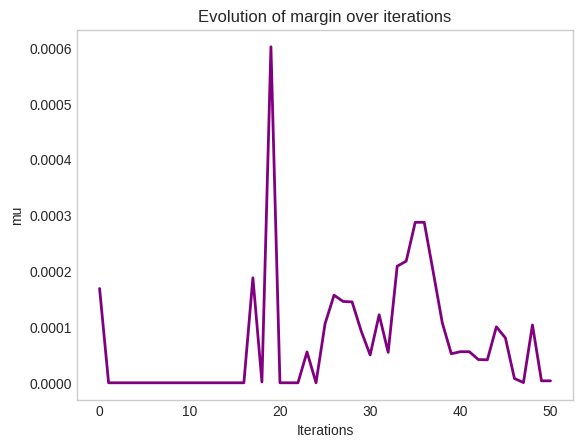

04:14:48 | INFO | ml_moo | Fit runtime: 437.92 seconds


In [11]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

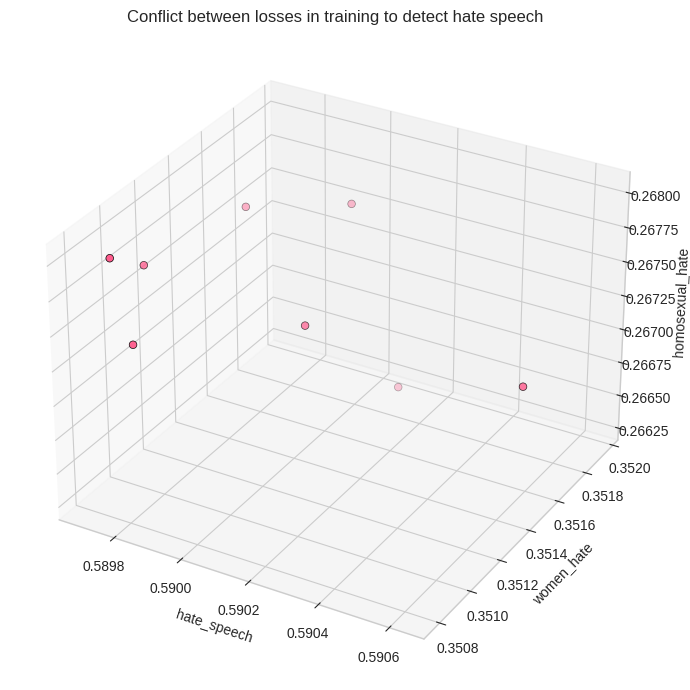

In [12]:
title="Conflict between losses in training to detect hate speech"
plot_pareto_3d(objectives=objs, 
               labels=tuple(task_names), 
               title=title,
               #point = equal.objs,
               color="#FF5C8D"
               )

04:14:48 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 300, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
04:14:48 | DEBUG | ml_moo | Finding 1th individual minimum
Epoch 1/3: 100%|██████████| 241/241 [00:02<00:00, 112.47it/s]


Epoch 1 - Average loss: 0.2300


Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 106.69it/s]


Epoch 2 - Average loss: 0.2261


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 111.88it/s]


...

Epoch 2 - Average loss: 0.1821


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 118.82it/s]


Epoch 3 - Average loss: 0.1820


04:21:53 | DEBUG | ml_moo | Calculated weights: [0.77350256 0.22649744 0.        ]
04:21:53 | DEBUG | ml_moo | Importance: 8.001665713697204e-05
04:21:53 | DEBUG | ml_moo | Global lower bound (y*): [0.58905126 0.35074246 0.26658537]
04:21:53 | DEBUG | ml_moo | Iteration 51
04:21:53 | DEBUG | ml_moo | Solutions list: [array([0.58922118, 0.35099315, 0.26679869]), array([0.58946666, 0.35092224, 0.2666786 ]), array([0.58927899, 0.35093698, 0.26741657]), array([0.58937113, 0.35086718, 0.26681165]), array([0.58942445, 0.35074246, 0.26735054]), array([0.58905126, 0.35157345, 0.26705947]), array([0.58953189, 0.35124532, 0.26658537])]


new solution added [0.58922118 0.35099315 0.26679869]
solution dominated [0.58936554 0.35127658 0.26706762]


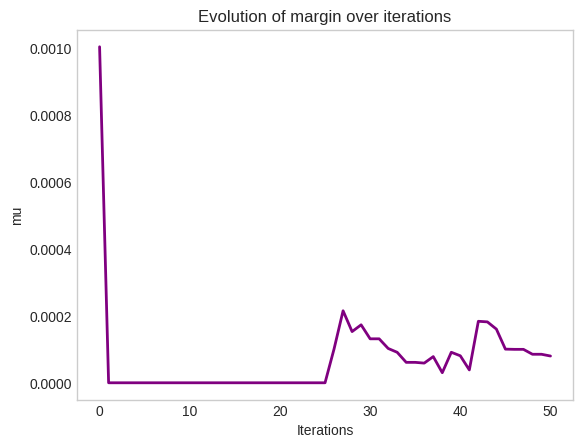

04:21:53 | INFO | ml_moo | Fit runtime: 424.76 seconds


In [ ]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names,
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

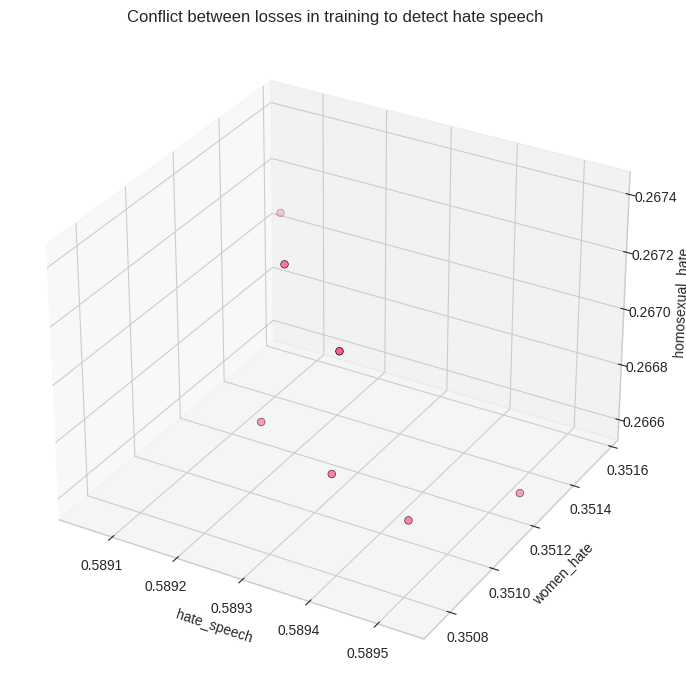

In [14]:
title="Conflict between losses in training to detect hate speech"
plot_pareto_3d(objectives=objs, 
               labels=tuple(task_names), 
               title=title,
               #point = equal.objs,
               color="#FF5C8D"
               )

### Random Weights

In [ ]:
method = 'random_weight'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

04:21:53 | WARNING | ml_moo | Ignored parameters for random_weights: {'nodeTimeLimit', 'targetGap', 'nodeGap'}
04:21:53 | DEBUG | ml_moo | Filtered parameters for random_weights: {'targetSize': 300, 'norm': False}
04:21:53 | DEBUG | ml_moo.moo.random_weights | Finding 1th individual minima
Epoch 1/3: 100%|██████████| 241/241 [00:01<00:00, 121.37it/s]


Epoch 1 - Average loss: 0.2241


Epoch 2/3: 100%|██████████| 241/241 [00:01<00:00, 120.57it/s]


Epoch 2 - Average loss: 0.2209


Epoch 3/3: 100%|██████████| 241/241 [00:01<00:00, 121.73it/s]


...

Epoch 3 - Average loss: 0.1860


04:55:32 | DEBUG | ml_moo.moo.random_weights | 257th solution
Epoch 1/3: 100%|██████████| 241/241 [00:02<00:00, 116.47it/s]


Epoch 1 - Average loss: 0.1787


Epoch 2/3:  69%|██████▉   | 166/241 [00:01<00:00, 113.92it/s]


KeyboardInterrupt: 

## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

In [ ]:
from ml_moo.analysis.moo_analyzer import Analyzer

12:55:30 | WARNING | ml_moo | [Methods have different numbers of solutions: {300, 6, 7}


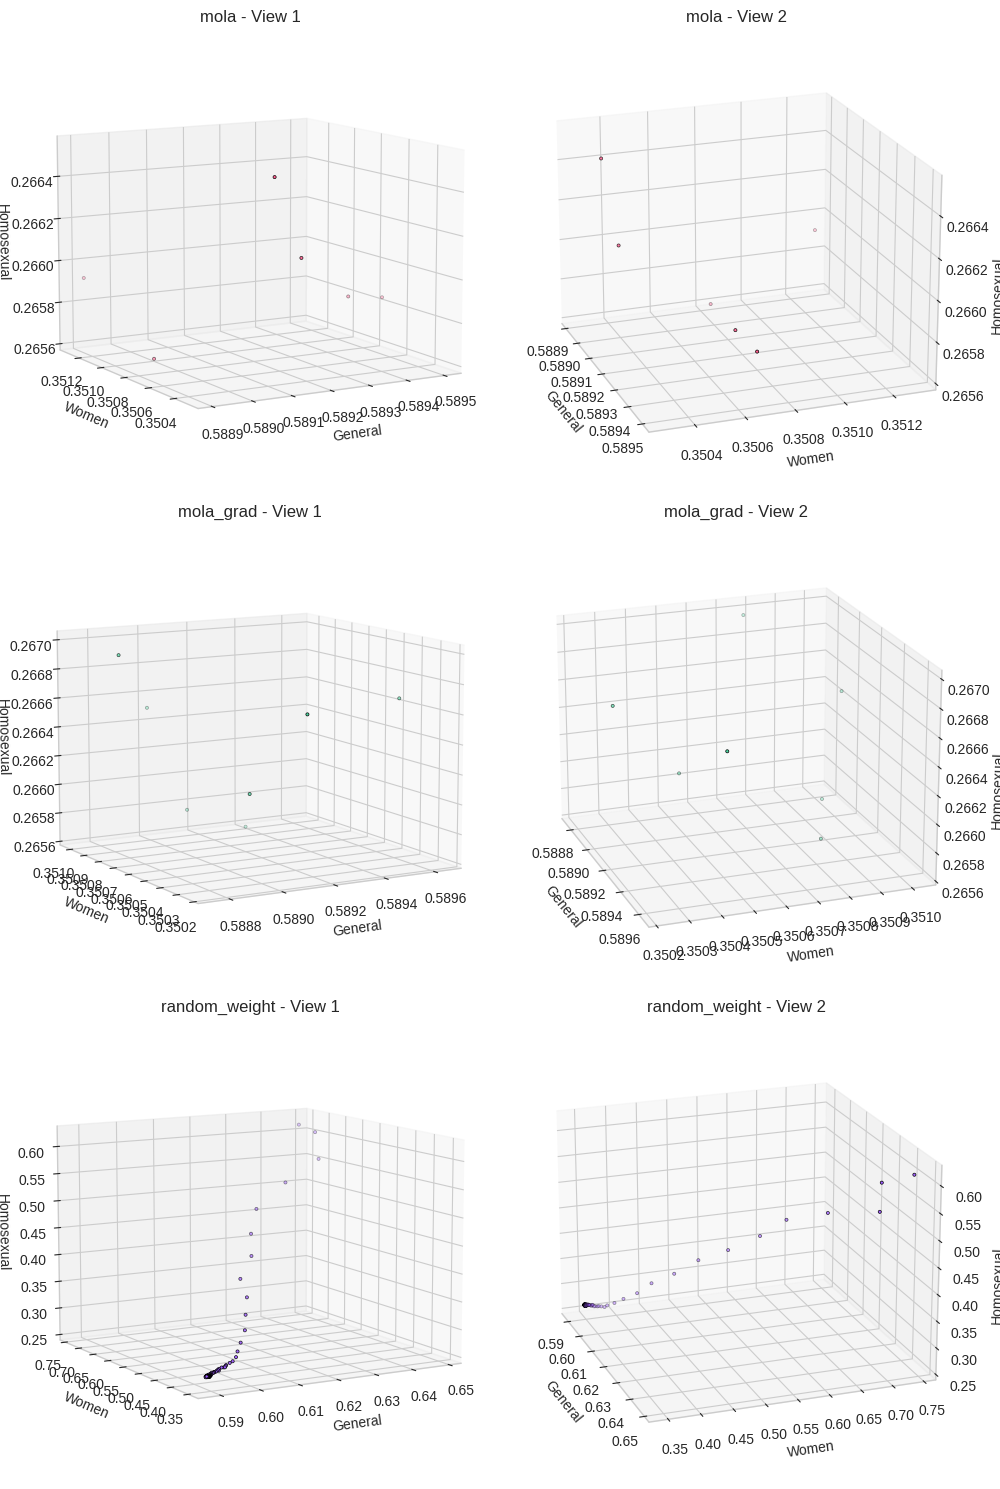

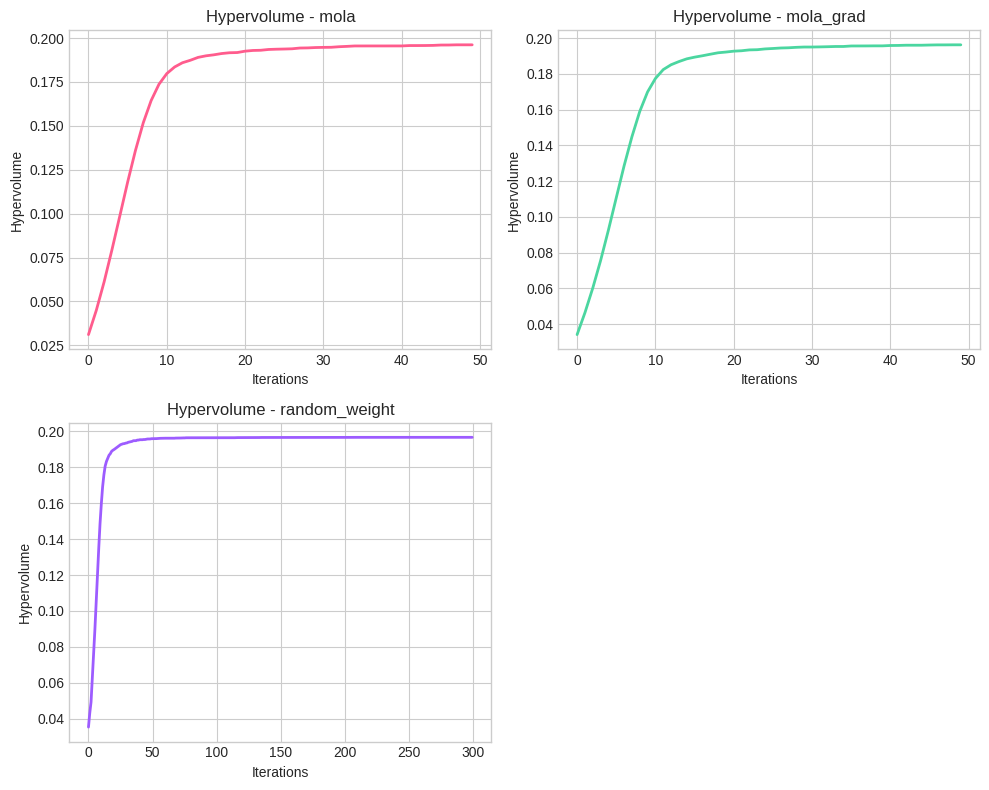

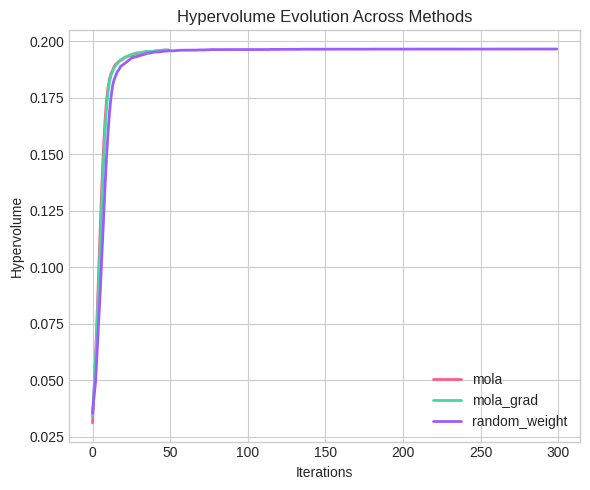

[Analyzer] Visualization complete.


In [ ]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

colors_pareto = ['#FF5C8D', '#FF5C8D', '#FF5C8D']
colors_hv = ['#FF5C8D', '#4BD6A0', '#9D5CFF']
title = ""
axis_label = task_names
Analyzer.run_multiple(pareto_dict = pareto_dict,
                      hypervolumes_values = hypervolumes_dict,
                      show_pareto = True, 
                      show_hypervolume = True,
                      subplots = True,
                      subplots_hv = True,
                      colors_pareto=colors_hv,
                      colors_hv=colors_hv,
                      axis_label=axis_label
                      )

In [ ]:
from ml_moo.analysis.visualization import plot_pareto_3d_set_limit

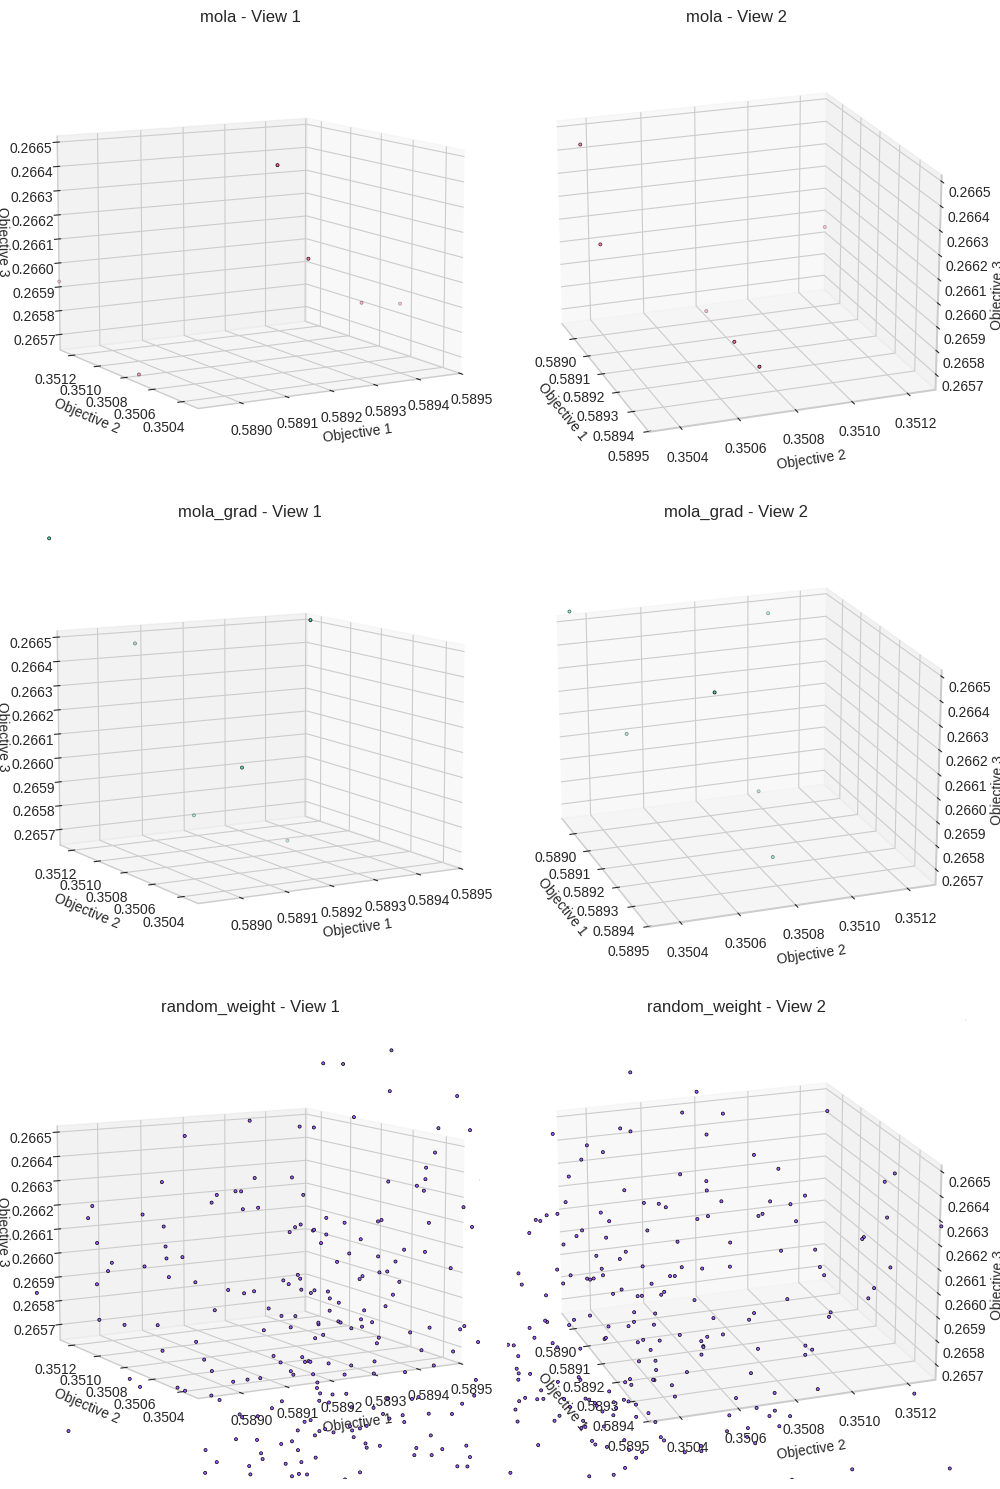

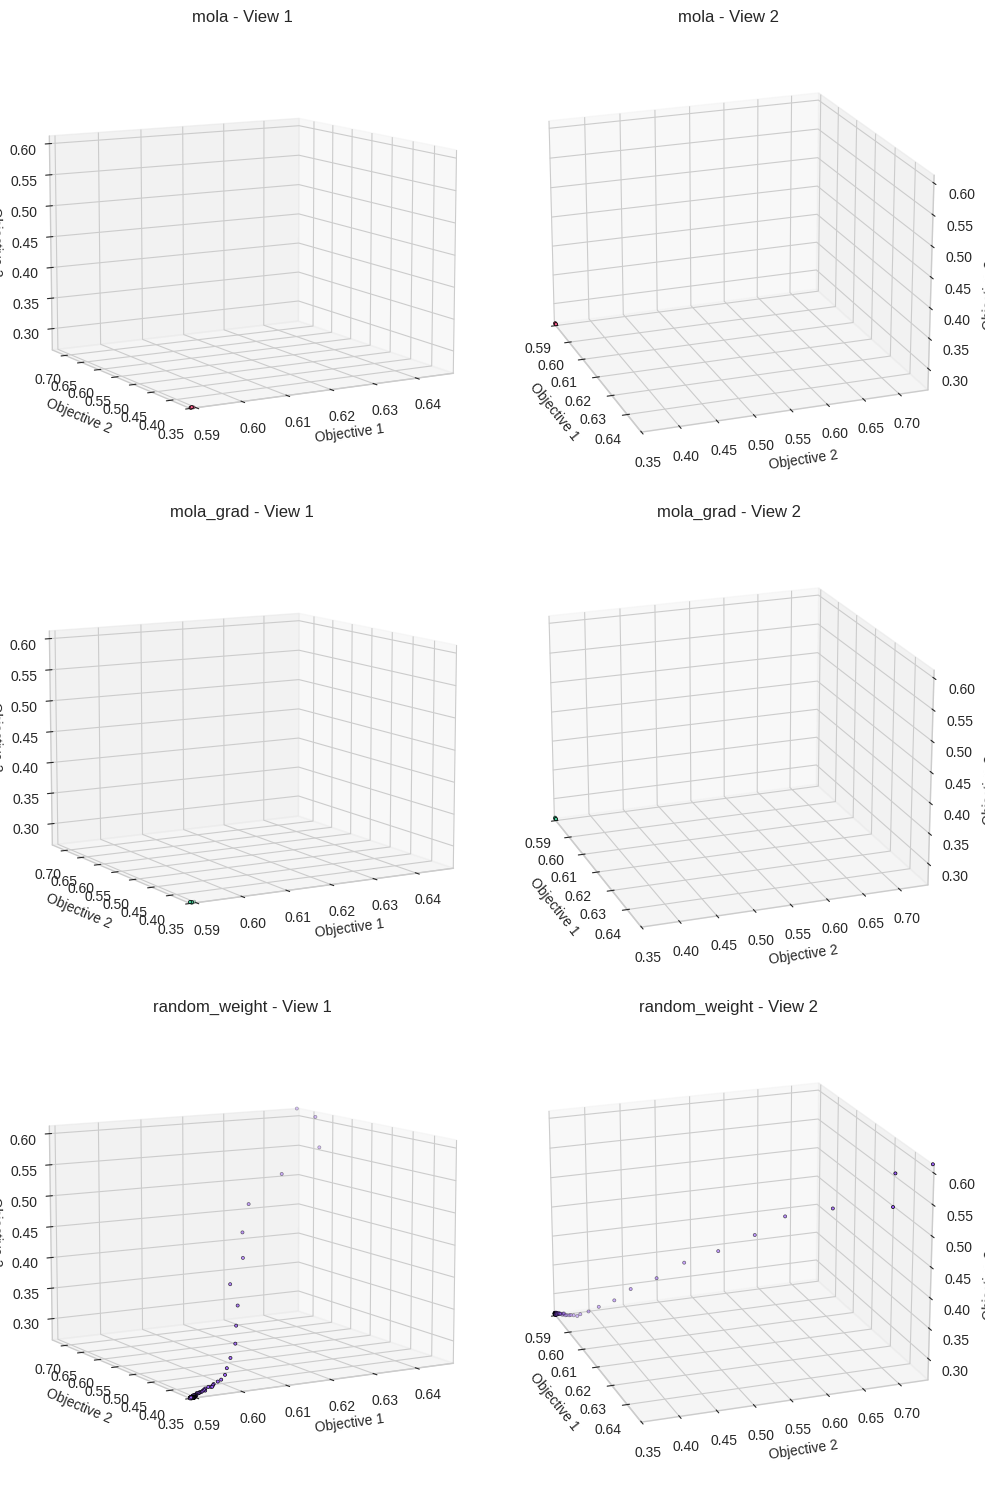

: 

In [ ]:
plot_pareto_3d_set_limit(pareto_dict, colors=colors_hv, axis_mode="first")
plot_pareto_3d_set_limit(pareto_dict, colors=colors_hv, axis_mode="global") 